In [1]:
# !pip install -e .[cplex]

In [2]:
import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit.circuit.library import (
    CXGate,
    RXXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
    XGate,
)
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import tqdm, trange
from gulps import logger
from gulps.core.invariants import GateInvariants
from gulps.core.isa import ContinuousISA, DiscreteISA
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.linear_program.cplex_lp import ContinuousISAConstraints
from gulps.viz.invariant_viz import plot_decomposition
from gulps.core.isa import ContinuousISA
from gulps import GulpsDecomposer
from qiskit.circuit.library import SwapGate
from qiskit.quantum_info.random import random_unitary
from gulps.core.invariants import GateInvariants
from gulps.viz.invariant_viz import plot_decomposition


# TODO move this into an importable module?
def fsim(theta, phi):
    qc = QuantumCircuit(2, name="fsim")
    qc.append(XXPlusYYGate(2 * theta), [0, 1])
    qc.cp(phi, 0, 1)
    return qc.to_gate()

In [3]:
# iswap_base = GateInvariants.from_unitary(iSwapGate().power(1.0))
# zz_base = GateInvariants.from_unitary(RXXGate(theta=np.pi / 2))
# swap_base = GateInvariants.from_unitary(SwapGate().power(1.0))
# base = fsim_base
# isa = ContinuousISA.from_base_gate(RXXGate(theta=np.pi / 2))
isa = ContinuousISA.from_base_gate(iSwapGate(), "iswap")
# fsim_base = GateInvariants.from_unitary(fsim(np.pi / 2, np.pi / 6).power(1.0))
decomposer = GulpsDecomposer(isa=isa)

(0.3166962482447585, 0.3166962482447585, 0.3166962482447585)
[array([0.15834812, 0.15834812, 0.        ]), array([ 0.31669625,  0.18365923, -0.13303702]), array([ 0.36806391,  0.34200736, -0.24001748])]


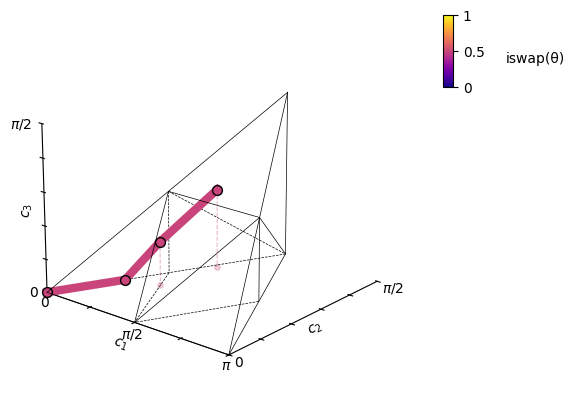

In [158]:
from gulps.core.isa import ContinuousISA
from gulps import GulpsDecomposer
from qiskit.circuit.library import SwapGate, RXXGate
from qiskit.quantum_info.random import random_unitary

isa = ContinuousISA.from_base_gate(iSwapGate(), "iswap")
isa.single_qubit_cost = 0.0
decomposer = GulpsDecomposer(isa=isa)
# decomposer(random_unitary(4, seed=0))
target = GateInvariants.from_unitary(random_unitary(4))
r = decomposer._best_decomposition(target)
print(r.parameters)
print([ri.weyl for ri in r.intermediates])
plot_decomposition(r.intermediates, r.sentence, decomposer.isa, r.parameters);

[array([0.15834812, 0.15834812, 0.        ]), array([ 0.31669625,  0.20971578, -0.10698047]), array([ 0.36806391,  0.34200736, -0.24001748])]


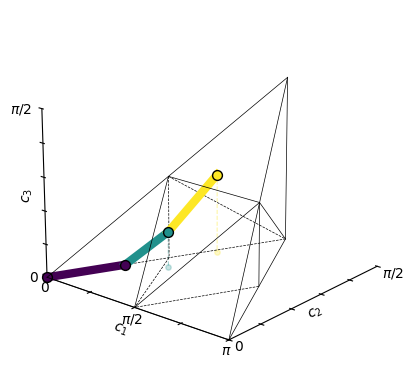

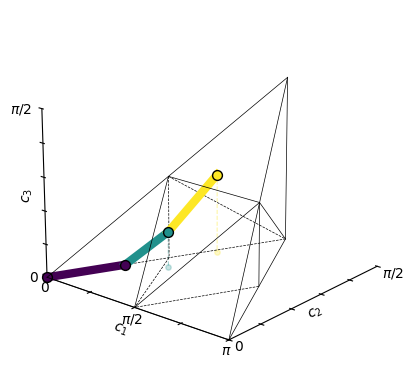

In [159]:
from gulps.linear_program.scipy_lp import MinimalOrderedISAConstraints

discrete_lp = MinimalOrderedISAConstraints(r.sentence)
r2 = discrete_lp.solve(target)
print([ri.weyl for ri in r2.intermediates])
plot_decomposition(r2.intermediates)

In [68]:
zz = GateInvariants.from_unitary(RXXGate(theta=np.pi), name="zz")
swap = GateInvariants.from_unitary(SwapGate(), name="swap")
isa = ContinuousISA(
    gate_set=[zz, swap],
    cost_dict={zz: 1.0, swap: 1.5},
    single_qubit_cost=0.1,
    max_depth=3,
)
decomposer = GulpsDecomposer(isa=isa)

(0.5000000000000002, 0.5000000000000002)


/home/evm9/hetero_isas/src/gulps/viz/invariant_viz.py:219: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(
/home/evm9/hetero_isas/src/gulps/viz/invariant_viz.py:233: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


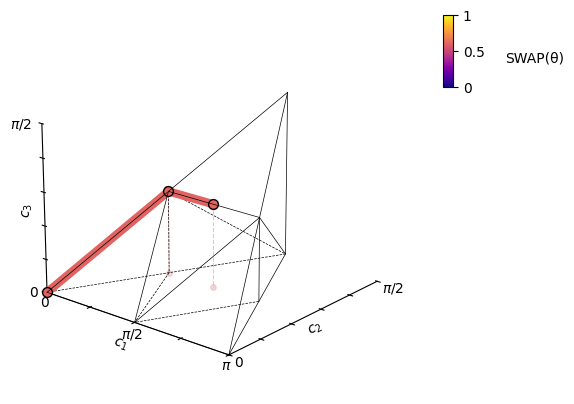

In [69]:
isa = ContinuousISA.from_base_gate(SwapGate(), "SWAP")
decomposer = GulpsDecomposer(isa=isa)
target = GateInvariants.from_weyl((0.5, 0.25, 0.25))
# target = GateInvariants.from_unitary(random_unitary(4))
ret = decomposer._best_decomposition(target)
print(ret.parameters)
plot_decomposition(ret.intermediates, ret.sentence, decomposer.isa, ret.parameters)
decomposer(target.unitary)

100%|██████████| 1000/1000 [00:00<00:00, 1255.24it/s]


(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

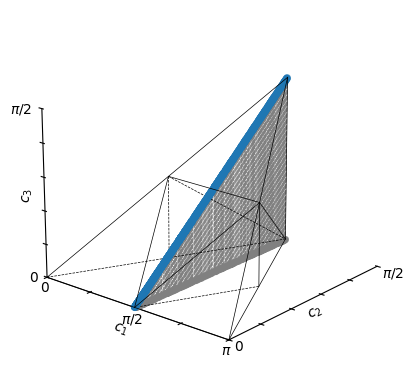

In [71]:
invariant_list = []
for i in trange(1000):
    qc = QuantumCircuit(2)
    qc.append(SwapGate().power(0.5), [0, 1])
    # qc.append(
    #     GateInvariants.from_weyl([0.36186093, 0.26444059, 0.26444059]).unitary, [0, 1]
    # )
    qc.append(
        UGate(
            np.random.uniform(0, 0 * 2 * np.pi),
            np.random.uniform(0, 0 * 2 * np.pi),
            np.random.uniform(0, 0 * 2 * np.pi),
        ),
        [0],
    )
    qc.append(
        UGate(
            np.random.uniform(0, 2 * np.pi),
            np.random.uniform(0, 0 * 2 * np.pi),
            np.random.uniform(0, 0 * 2 * np.pi),
        ),
        [1],
    )
    qc.append(SwapGate().power(0.5), [0, 1])
    target = GateInvariants.from_unitary(Operator(qc))
    invariant_list.append(target)

from gulps.viz.invariant_viz import scatter_plot

scatter_plot(invariant_list)

In [61]:
GateInvariants.from_unitary(SwapGate().power(0.5)).makhlin

[-4.500067939282711e-17, -0.25000000000000006, -1.8000271757130834e-16]

In [76]:
GateInvariants.from_unitary(SwapGate().power(0.5169404449744961)).weyl

array([ 0.25847022,  0.25847022, -0.25847022])

In [77]:
GateInvariants.from_unitary(SwapGate().power(0.20678140734277392)).weyl

array([ 0.1033907,  0.1033907, -0.1033907])

In [ ]:
0.1033907 + 0.25847022

0.36186092

In [75]:
[x.weyl for x in invariant_list]

[array([ 0.36186093,  0.20439286, -0.20439286]),
 array([ 0.36186093,  0.16521408, -0.16521408]),
 array([ 0.36186093,  0.16139064, -0.16139064]),
 array([ 0.36186093,  0.19929018, -0.19929018]),
 array([ 0.36186093,  0.19225115, -0.19225115]),
 array([ 0.36186093,  0.23042701, -0.23042701]),
 array([ 0.36186093,  0.24305067, -0.24305067]),
 array([ 0.36186093,  0.18641861, -0.18641861]),
 array([ 0.36186093,  0.25439445, -0.25439445]),
 array([ 0.36186093,  0.16602051, -0.16602051]),
 array([ 0.36186093,  0.24725714, -0.24725714]),
 array([ 0.36186093,  0.15770521, -0.15770521]),
 array([ 0.36186093,  0.23251056, -0.23251056]),
 array([ 0.36186093,  0.22496676, -0.22496676]),
 array([ 0.36186093,  0.15633698, -0.15633698]),
 array([ 0.36186093,  0.33267002, -0.33267002]),
 array([ 0.36186093,  0.188592  , -0.188592  ]),
 array([ 0.36186093,  0.17328916, -0.17328916]),
 array([ 0.36186093,  0.15664671, -0.15664671]),
 array([ 0.36186093,  0.15685628, -0.15685628]),
 array([ 0.36186093,

In [70]:
# comment out what you don't want or add your own
isa = [
    (SwapGate().power(0.5169404449744961), 0.5169404449744961, "s1"),
    (SwapGate().power(0.20678140734277392), 0.20678140734277392, "s2"),
]
gate_set, costs, names = zip(*isa)
isa = DiscreteISA(gate_set, costs, names, precompute_polytopes=True)
decomposer = GulpsDecomposer(isa=isa)

from gulps.core.coverage import coverage_report

if hasattr(decomposer.isa, "coverage_set"):
    report = coverage_report(decomposer.isa.coverage_set)

KeyboardInterrupt: 

#### 
Decomp concept

In [141]:
# Warm-start to trigger JIT compilation (optional)
_ = decomposer(random_unitary(4, seed=0))

RuntimeError: Optimization failed: Stage 1 residual 3.78e-01, Stage 2 residual 2.76e-01

(0.546855713483115, 0.1972800070020294, 0.19728000700202938)


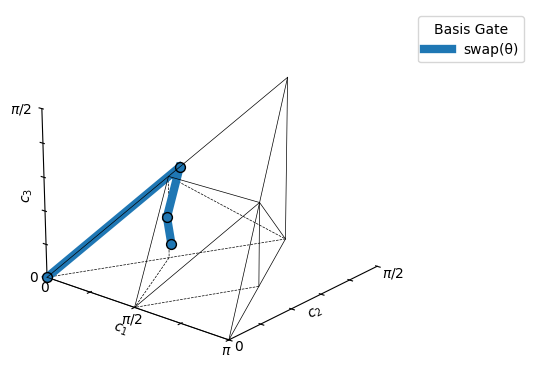

In [142]:
r = decomposer._best_decomposition(GateInvariants.from_unitary(random_unitary(4)))
# r = decomposer._best_decomposition(GateInvariants.from_unitary(iSwapGate()))
print(r.parameters)
plot_decomposition(r.intermediates, r.sentence, isa);

In [7]:
logger.setLevel("INFO")
N = 100

fidelities = []
all_timings = []
failures = 0

for idx in trange(N, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        v = Operator(decomposer(u))
        fid = average_gate_fidelity(u, v)

        if fid < 1 - 1e-8:
            raise ValueError(f"Fidelity too low: {fid:.8f}")

        fidelities.append(fid)
        all_timings.append(decomposer.last_timing)

    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1

# === Fidelity Statistics ===
fidelities = np.array(fidelities)
print(f"\n✔ Completed {len(fidelities)} successful runs (out of {N})")
print(f"  → Failures: {failures}")
print(f"  → Median Fidelity: {np.median(fidelities)}")
print(f"  → Mean Fidelity:   {np.mean(fidelities)}")
print(f"  → Min Fidelity:    {np.min(fidelities)}")

# === Timing Statistics ===
if all_timings:
    phase_names = list(all_timings[0].keys())
    timing_array = np.array([[t[k] for k in phase_names] for t in all_timings])

    print("\nAverage phase durations:")
    for k, mean_time in zip(phase_names, timing_array.mean(axis=0)):
        print(f"  {k:>10}: {mean_time:.4f} s")

    print(f"\n  Total average time: {timing_array.sum(axis=1).mean():.4f} s")
else:
    print("No successful timings collected.")

Decomposing random unitaries:   0%|          | 0/100 [00:00<?, ?it/s]

Decomposing random unitaries: 100%|██████████| 100/100 [00:12<00:00,  8.24it/s]


✔ Completed 100 successful runs (out of 100)
  → Failures: 0
  → Median Fidelity: 1.0
  → Mean Fidelity:   1.0000000000000002
  → Min Fidelity:    0.9999999999999989

Average phase durations:
  lp_sentence: 0.0905 s
    segments: 0.0295 s

  Total average time: 0.1199 s


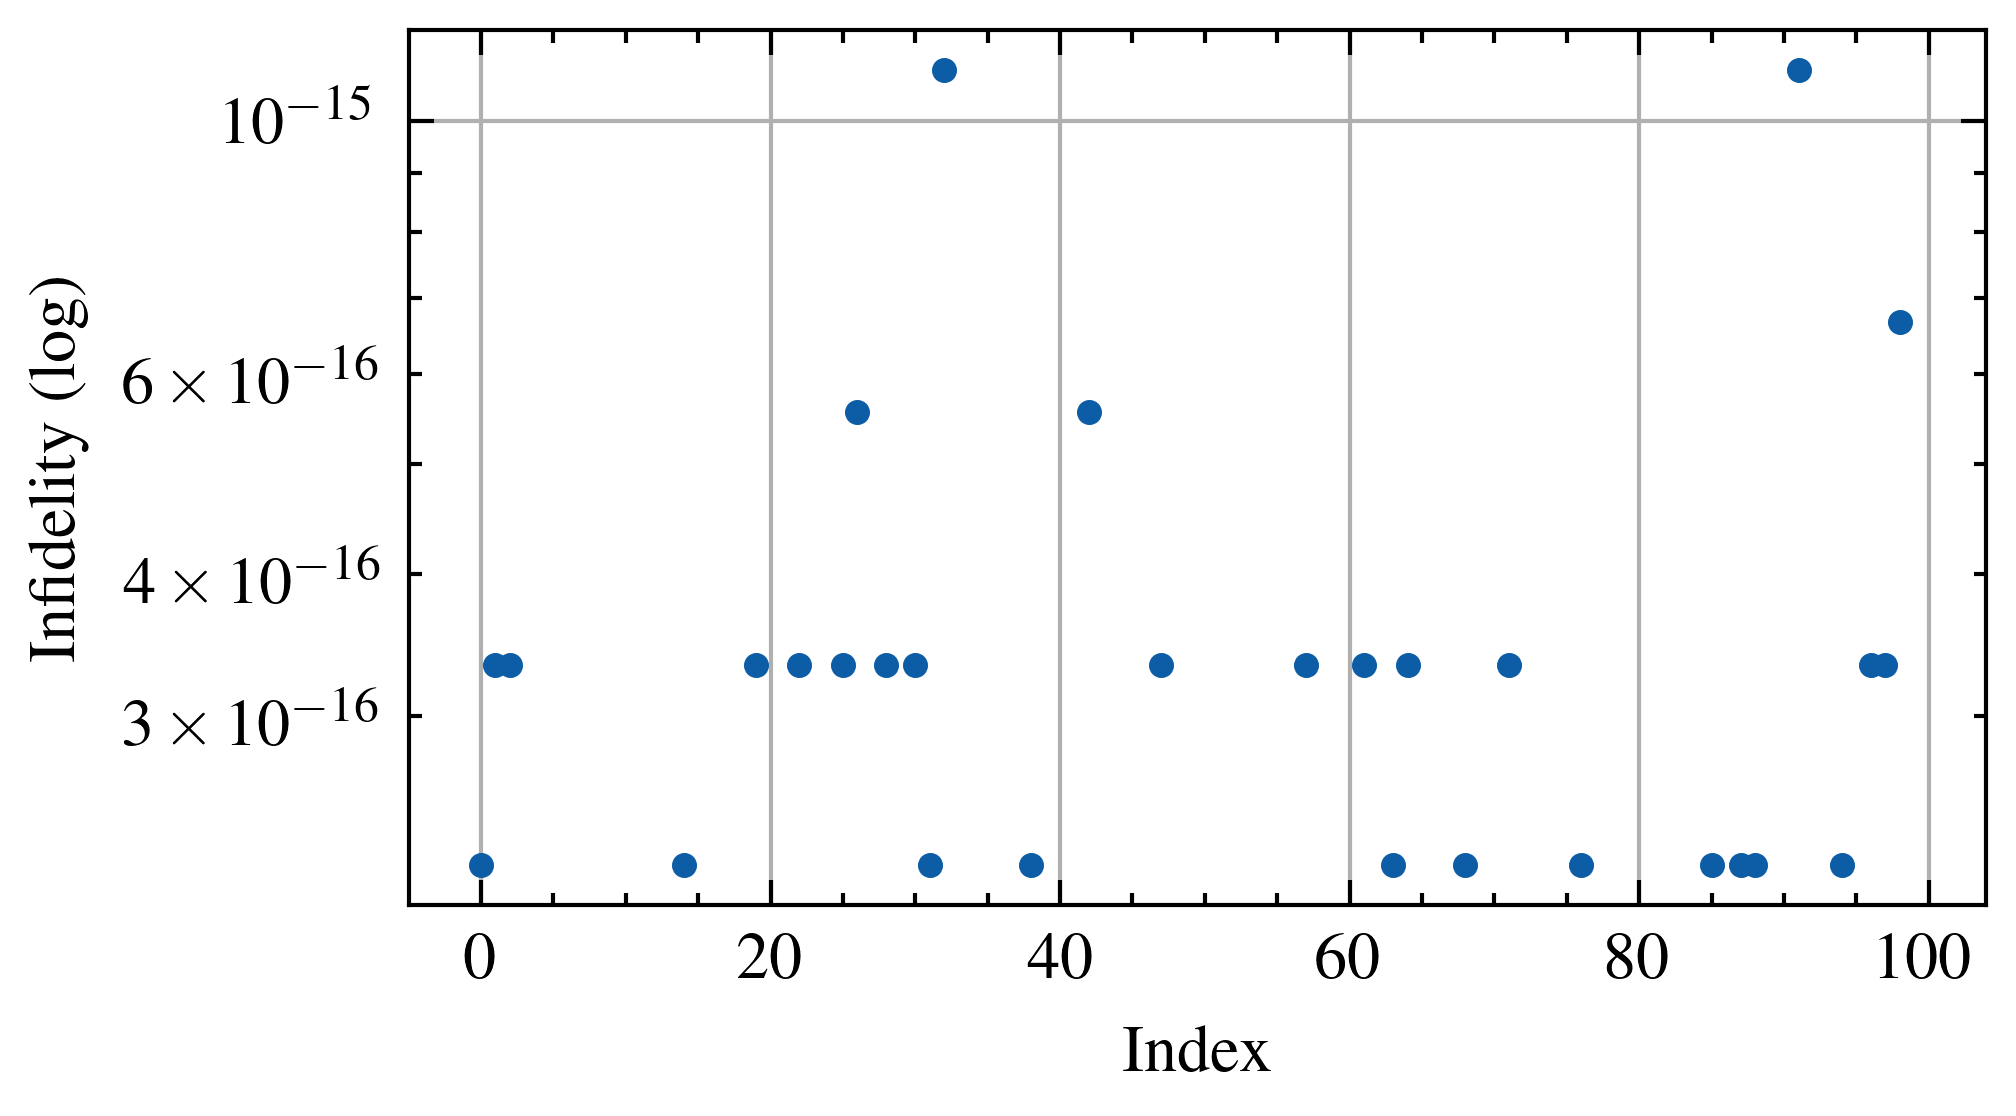

In [8]:
# make a plot for the fidelities
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, ax = plt.subplots(figsize=(3.5, 2))
    ax.plot(1 - fidelities, marker="o", markersize=2, linestyle="None")
    ax.set_xlabel("Index")
    ax.set_ylabel("Infidelity (log)")
    ax.set_yscale("log")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

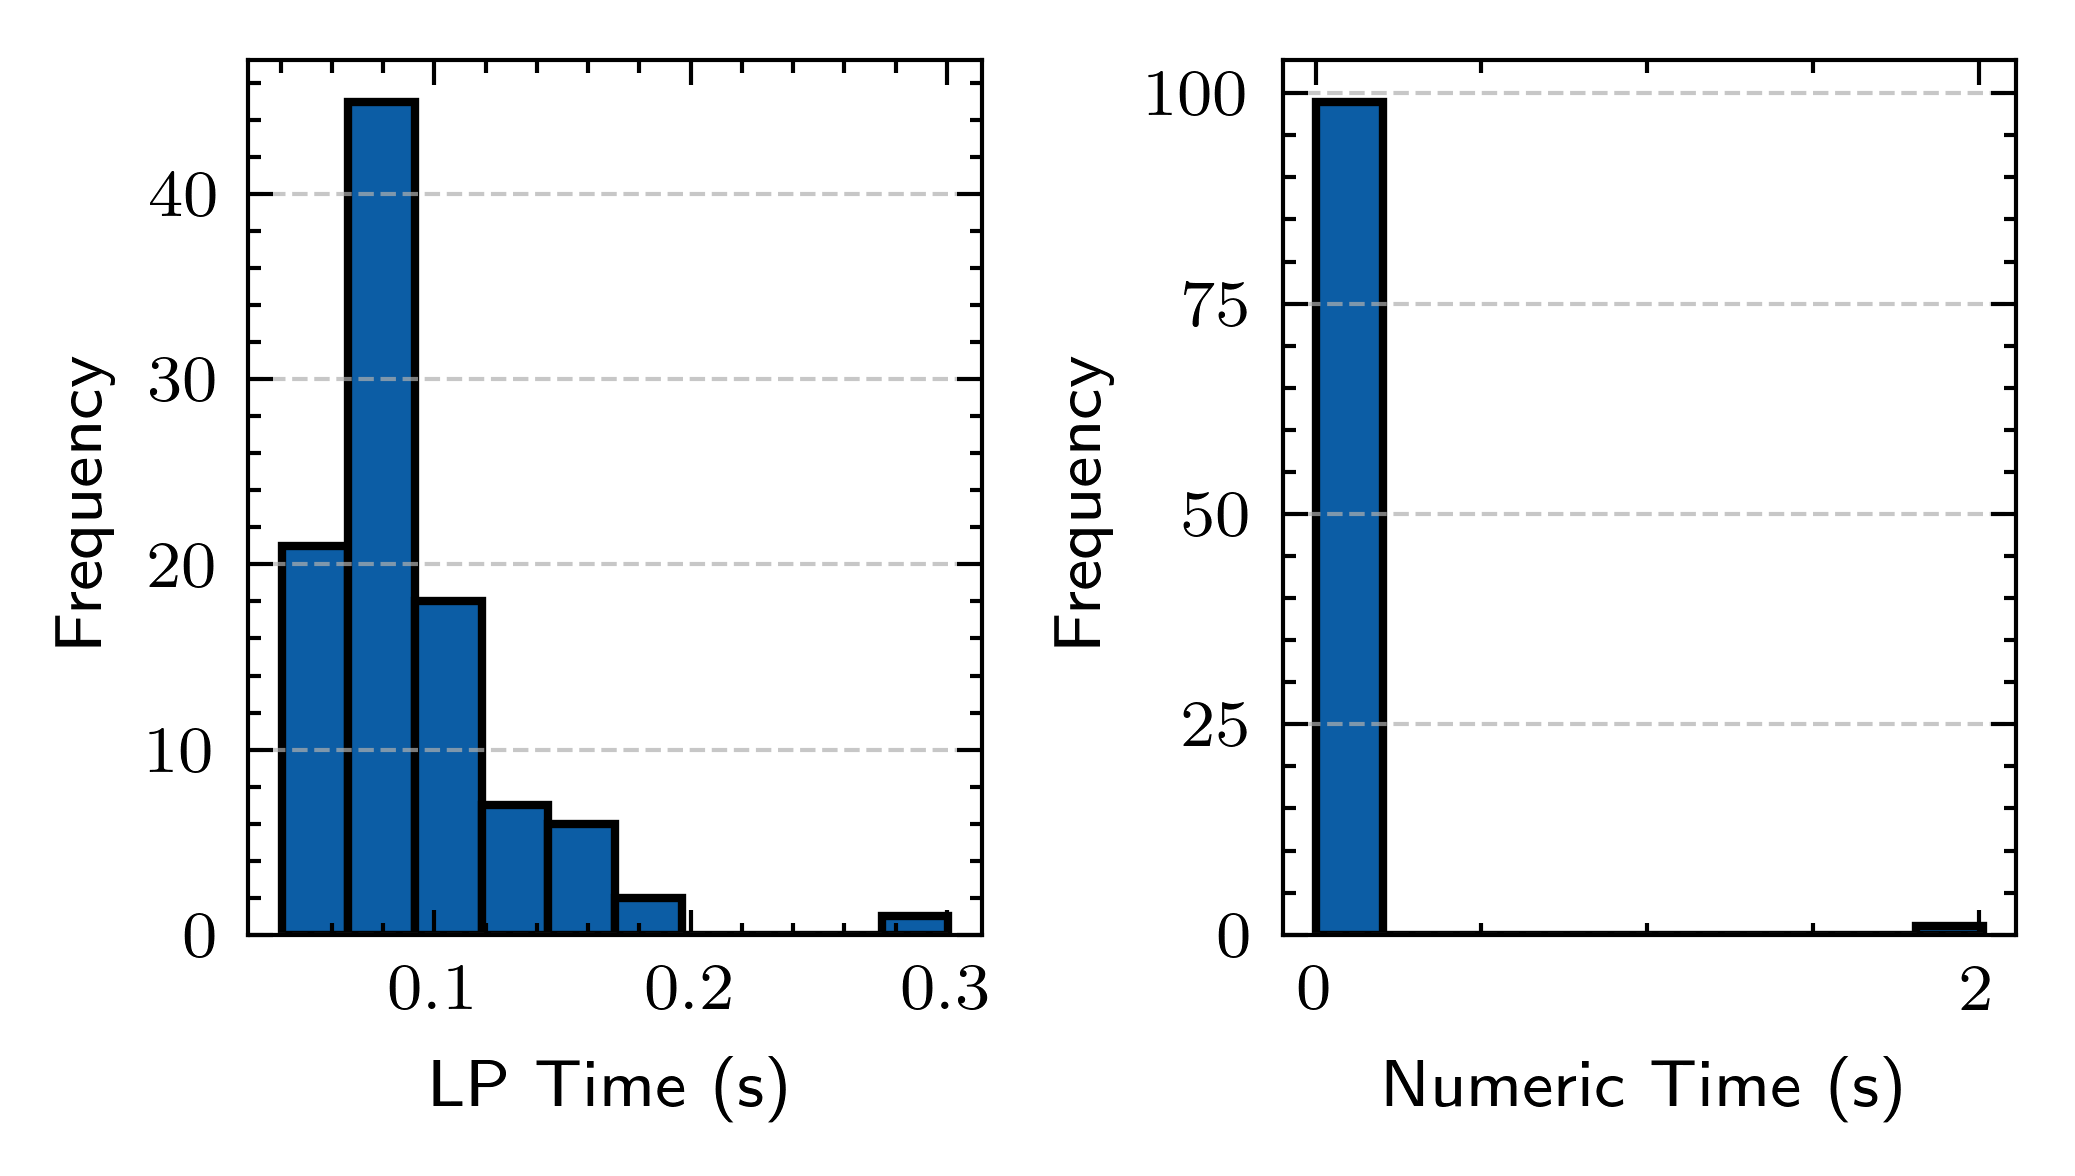

In [9]:
# Convert list of dicts to lists of values
lp_times = [d["lp_sentence"] for d in all_timings]
numeric_times = [d["segments"] for d in all_timings]

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(3.5, 2))

    axes[0].set_xlabel("LP Time (s)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)
    axes[0].hist(lp_times, edgecolor="black")

    axes[1].set_xlabel("Numeric Time (s)")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)
    axes[1].hist(numeric_times, edgecolor="black")

    fig.tight_layout()
plt.show()

#### hist
Let's look at the fractional powers that most commonly appear in decompositions. The LP is incentivized to minimize the sum cost, and secondly keep the sentence length short. This either means we select pairs of big gates and little gates (bimodal drivers and putters) or an average indiviudal gate (unimodal iron club). This can be sensitive to the maximum sequence_length, secondary objective offset tolerance, and fractional power lower bound parameters.

100%|██████████| 10000/10000 [08:19<00:00, 20.00it/s]


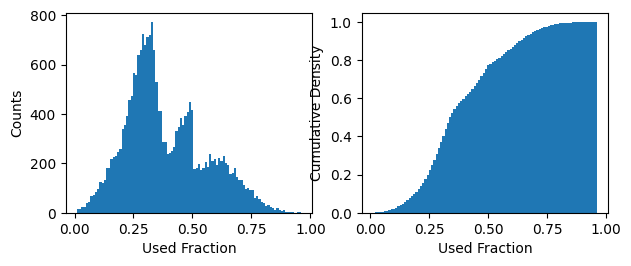

In [21]:
used_fractions = []
N = 10000
for i in tqdm(range(N)):
    target = GateInvariants.from_unitary(random_unitary(dims=4))
    sol = decomposer._best_decomposition(target)
    used_fractions.extend(sol.parameters)

nbins = int(np.sqrt(N))
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))
axs = axes[0]
axs.hist(used_fractions, bins=nbins)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Counts")

axs = axes[1]
axs.hist(used_fractions, bins=nbins, cumulative=True, density=True)
axs.set_xlabel("Used Fraction")
axs.set_ylabel("Cumulative Density")

plt.show()

#### 
Next, let's compare a decomposition of iSWAP into a discrete fSim gate family against the continuous fSim gate family.

0.8 (0.4, 0.4)


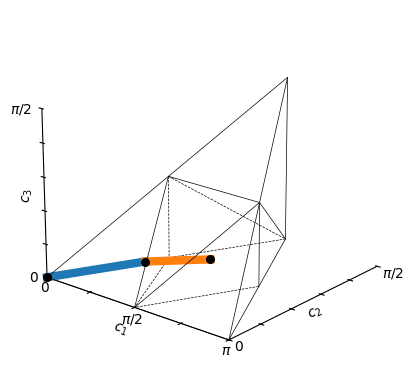

In [29]:
target = GateInvariants.from_weyl((0.4, 0.3, 0.0))
sol = decomposer._best_decomposition(target)
print(sum(sol.parameters), sol.parameters)
render_path(sol.intermediates)

In [1]:
# different combinations of fractional powers may get you farther or closer to the continuous lower bound
# (1/3, 1/7) works pretty well
isa = [
    (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 7), 1 / 7, "sqrt7fsim"),
]
gate_set, costs, names = zip(*isa)
isa = DiscreteISA(gate_set, costs, names)
decomposer = GulpsDecomposer(isa=isa)
sentence_out, example_intermediates = decomposer._best_decomposition(target_inv=target)
ks = [isa.cost_dict[s] for s in sentence_out]
print(sum(ks), ks)
render_path(example_intermediates);

NameError: name 'fsim' is not defined

Sweeping φ:   6%|▋         | 2/32 [00:00<00:03,  9.48it/s]

Sweeping φ: 100%|██████████| 32/32 [00:04<00:00,  7.36it/s]


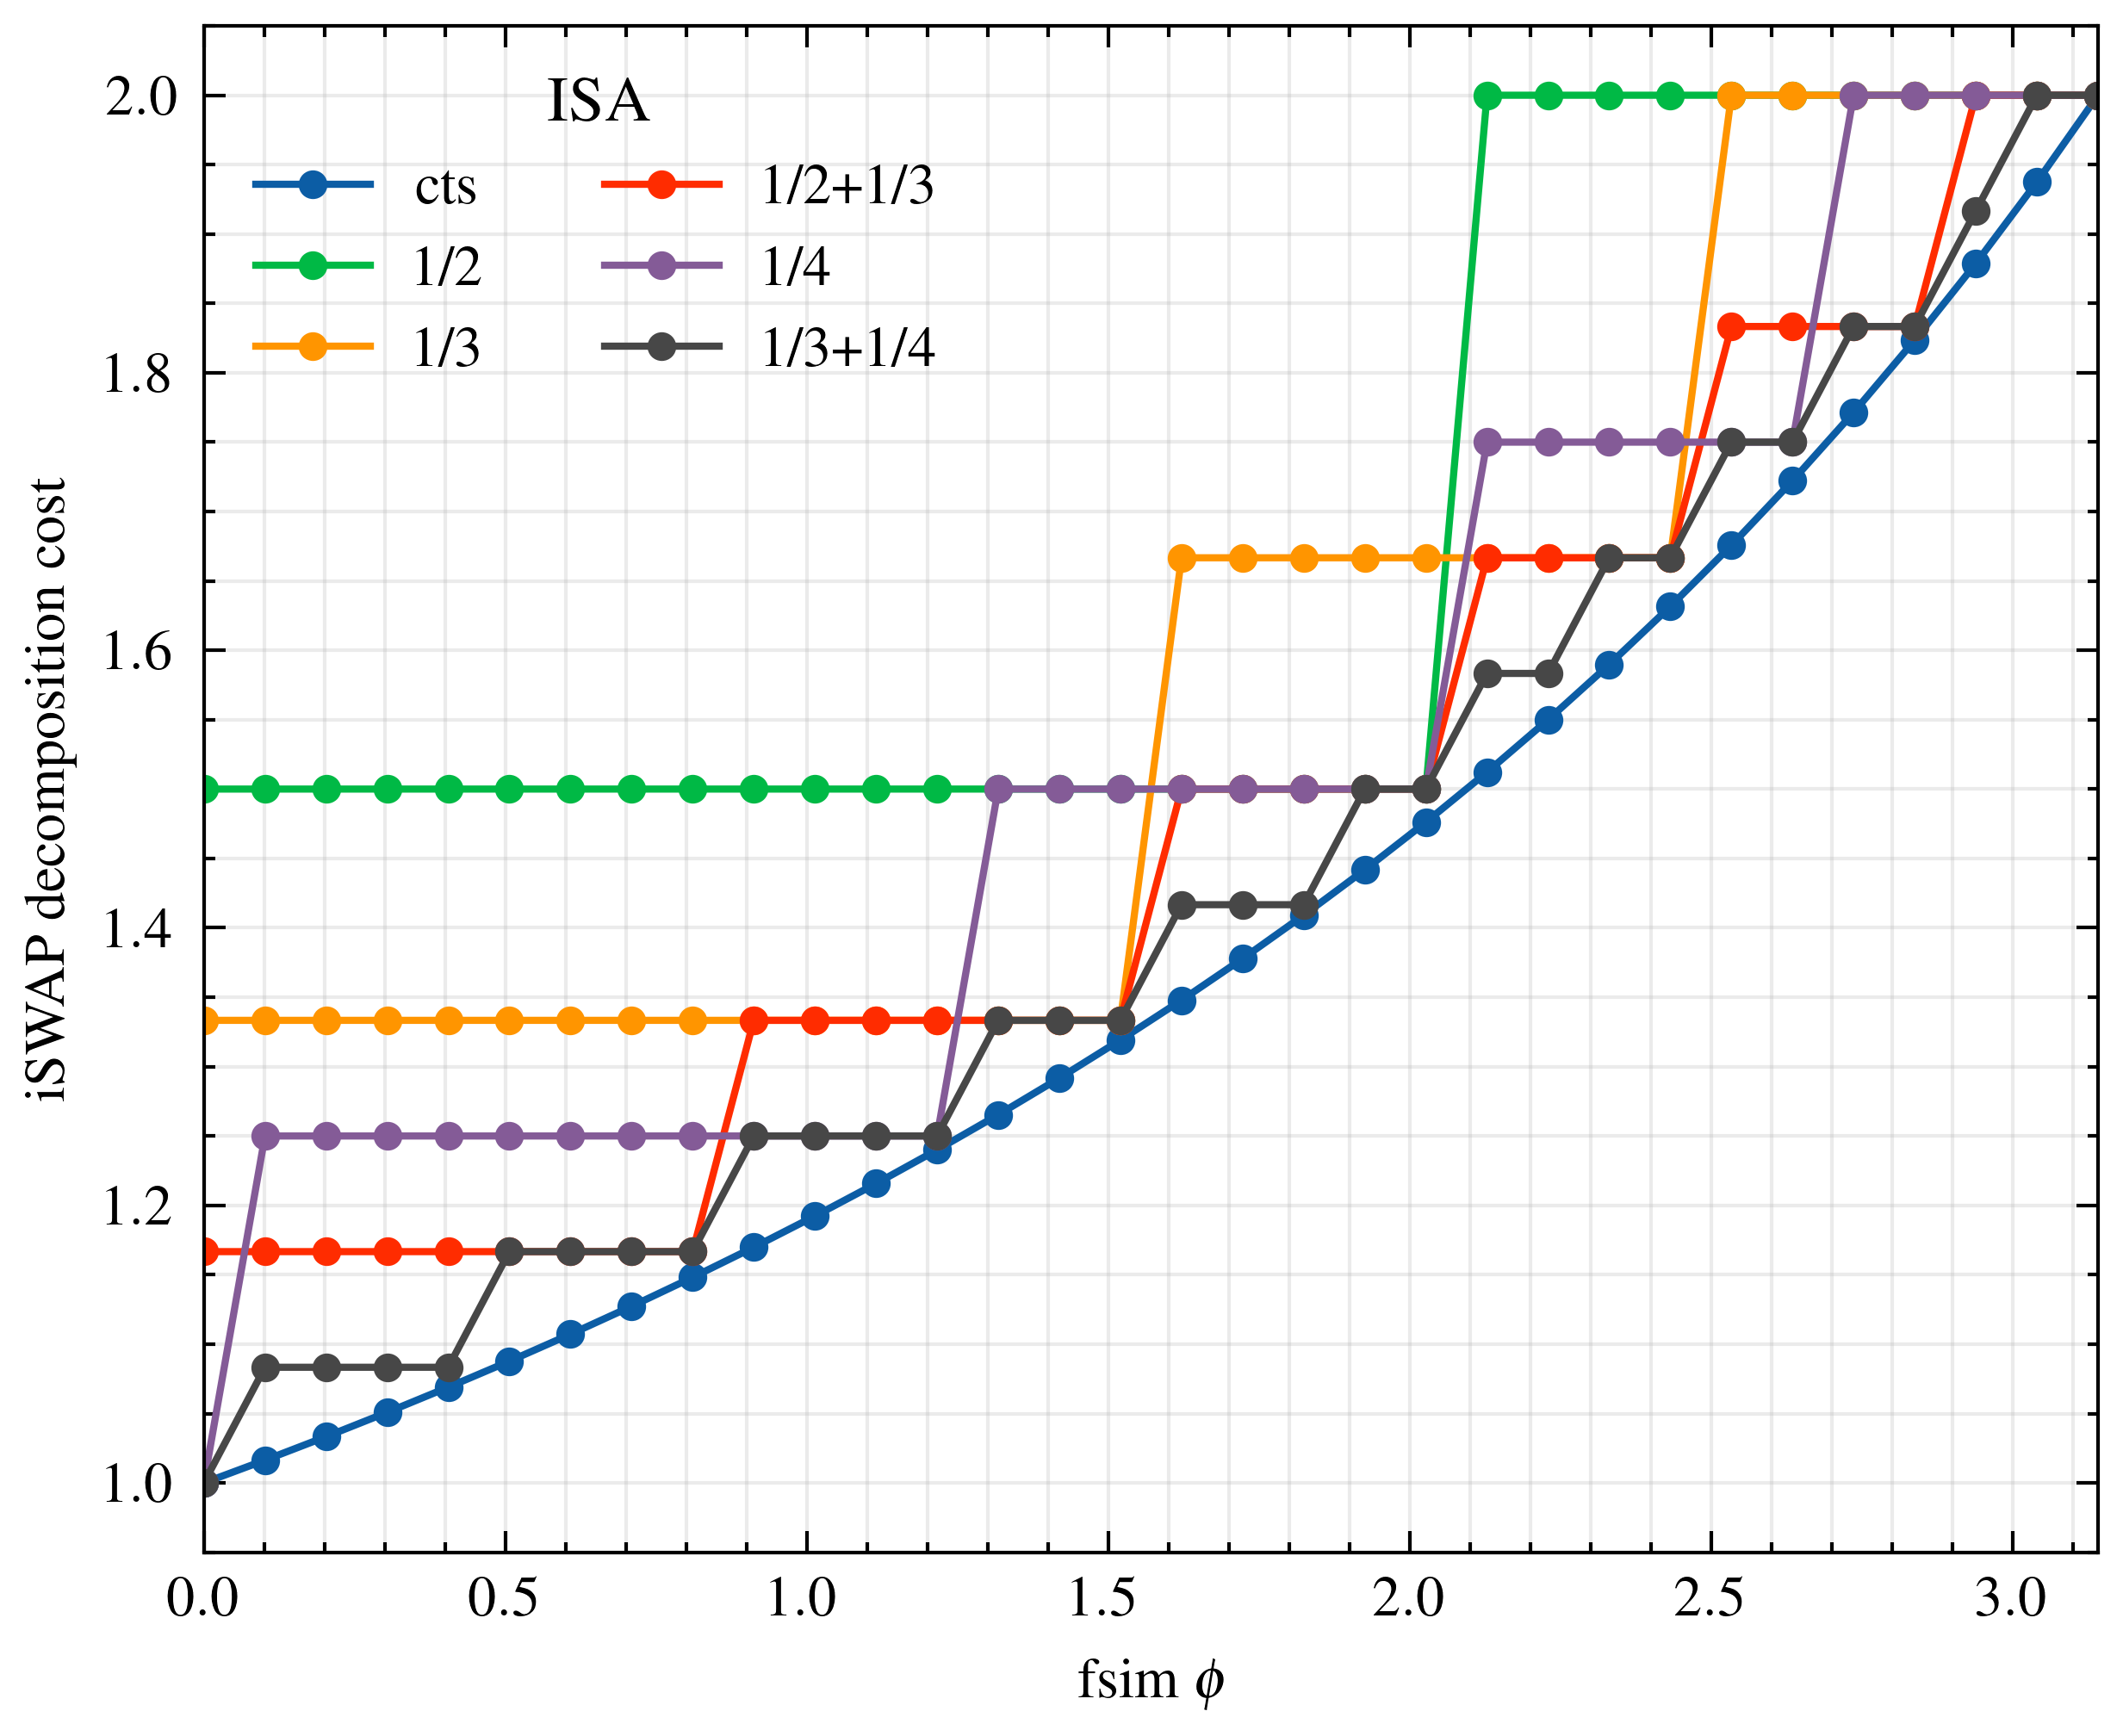

In [ ]:
# a more systematic search, shows the combinations of discrete powers can get closer to the continuous lower bound
# %%
target_inv = GateInvariants.from_unitary(iSwapGate())

ISA_SPECS = {
    "1/2": (0.5,),
    "1/3": (1 / 3,),
    "1/2+1/3": (0.5, 1 / 3),
    "1/4": (1 / 4,),
    "1/3+1/4": (1 / 3, 1 / 4),
}
LABEL_ORDER = ["cts", "1/2", "1/3", "1/2+1/3", "1/4", "1/3+1/4"]
MAX_SEQUENCE_LEN = 8  # for the CTS solver only


# ---------- evaluators ----------
def optimal_cost_continuous(phi: float) -> float:
    base = GateInvariants.from_unitary(fsim(np.pi / 2, phi).power(1.0))
    solver = ContinuousISAConstraints(
        base=base, max_sequence_length=MAX_SEQUENCE_LEN, offset=1e-6
    )
    solver.set_target(target_inv, rho_bool=False)
    _, _, ks = solver.solve(log_output=False)
    return float(np.sum(ks))


def best_discrete_cost(phi: float, fracs: tuple[float, ...]) -> float:
    base_gate = fsim(np.pi / 2, phi)
    isa = [
        (
            base_gate.power(fr),
            fr,
            (f"{int(fr)}" if fr >= 1 else f"{int(round(fr * 6))}/{6}"),
        )
        for fr in fracs
    ]
    gate_set, costs, names = zip(*isa)
    dec = GulpsDecomposer(
        gate_set=gate_set, costs=costs, names=names, precompute_polytopes=False
    )
    try:
        sentence_out, _ = dec._best_decomposition(target_inv=target_inv)
        if sentence_out is None:
            return np.nan
        return float(sum(dec.isa.cost_dict[g] for g in sentence_out))
    except Exception as e:
        print(f"Error occurred: {e}")
        return np.nan


# ---------- sweep ----------
phi_values = np.linspace(0.0, np.pi, 32)
series = {k: [] for k in LABEL_ORDER}

for phi in tqdm(phi_values, desc="Sweeping φ"):
    # optimal (continuous)
    series["cts"].append(optimal_cost_continuous(phi))
    # discrete
    for label in LABEL_ORDER:
        if label == "cts":
            continue
        series[label].append(best_discrete_cost(phi, ISA_SPECS[label]))

# ---------- plot ----------
with plt.style.context(["ieee", "use_mathtext", "science"]):
    fig, ax = plt.subplots(figsize=(4.25, 3.5))
    for label in LABEL_ORDER:
        ax.plot(phi_values, series[label], label=label, marker=".")
    ax.set_xlabel(r"$\mathrm{fsim}\ \phi$")
    ax.set_ylabel("iSWAP decomposition cost")
    ax.set_xlim(phi_values.min(), phi_values.max())
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(title="ISA", fontsize=8, title_fontsize=9, ncols=2)
    fig.tight_layout()
    plt.show()


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [01:21<00:00,  8.13s/it]


Text(0, 0.5, 'expected depth')

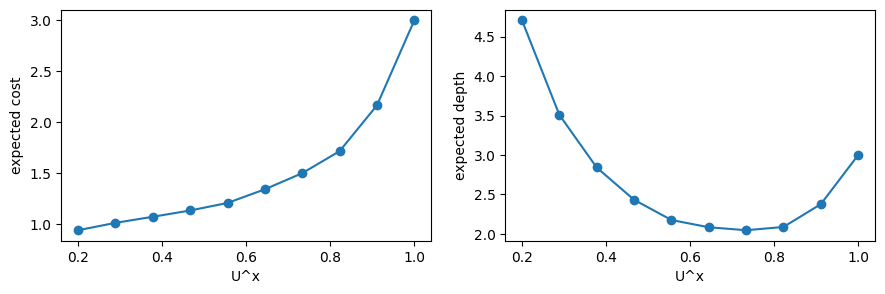

In [ ]:
from gulps.core.coverage import expected_costs
from gulps.gulps_decomposer import GulpsDecomposer

x = np.linspace(0.2, 1.0, 10)
y = []
for c in tqdm(x):
    isa = [
        (iSwapGate().power(c), c, "U"),
    ]
    gate_set, costs, names = zip(*isa)
    decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)
    if hasattr(decomposer.isa, "coverage_set"):
        y.append(expected_costs(decomposer.isa.coverage_set))

# print (y[0] vs x; y[1] vs x; y[2] vs x)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(3 * 3.5, 3.0))
axs = axes[0]
axs.plot(x, [v[0] for v in y], "-o")
axs.set_xlabel("U^x")
axs.set_ylabel("expected cost")

axs = axes[1]
axs.plot(x, [v[1] for v in y], "-o")
axs.set_xlabel("U^x")
axs.set_ylabel("expected depth")